### A + load_forecast_ahead + solar_ahead + wind_ahead + time + lags SELECTED 

## 1. Imports & Setup
Imports required libraries: PyTorch for modelling, NumPy and Pandas for data handling, Matplotlib for visualization, and scikit-learn for scaling.

In [227]:
import math
import copy
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
import random

### Manual seed 

In [228]:
SEED = 55

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

print(f"Random seed set to {SEED}")

Random seed set to 55


## 2. Data Loading
Loads the merged energy and weather dataset (35,064 rows x 62 columns) - hourly observations with energy production/consumption and weather features.

In [229]:
energy_weather = pd.read_csv('../../data/processed/energy_weather_merged.csv')
energy_weather.info()
print(f"\nShape: {energy_weather.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 62 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   time                             35064 non-null  object 
 1   date                             35064 non-null  object 
 2   hour                             35064 non-null  int64  
 3   forecast solar day ahead         35064 non-null  float64
 4   forecast wind onshore day ahead  35064 non-null  float64
 5   total load forecast              35064 non-null  float64
 6   total load actual                35064 non-null  float64
 7   price day ahead                  35064 non-null  float64
 8   price actual                     35064 non-null  float64
 9   gen_solar                        35064 non-null  float64
 10  gen_wind                         35064 non-null  float64
 11  gen_hydro                        35064 non-null  float64
 12  gen_pumped_hydro  

In [230]:
energy_weather[['time', 'gen_solar', 'total load actual', 'total load forecast']].head(36)

,time,gen_solar,total load actual,total load forecast
0,2014-12-31 23:00:00+00:00,49.0,25385.0,26118.0
1,2015-01-01 00:00:00+00:00,50.0,24382.0,24934.0
2,2015-01-01 01:00:00+00:00,50.0,22734.0,23515.0
3,2015-01-01 02:00:00+00:00,50.0,21286.0,22642.0
4,2015-01-01 03:00:00+00:00,42.0,20264.0,21785.0
5,2015-01-01 04:00:00+00:00,34.0,19905.0,21441.0
6,2015-01-01 05:00:00+00:00,34.0,20010.0,21285.0
7,2015-01-01 06:00:00+00:00,35.0,20377.0,21545.0
8,2015-01-01 07:00:00+00:00,54.0,20094.0,21443.0
9,2015-01-01 08:00:00+00:00,743.0,20637.0,21560.0


## 3. Feature & Target Definition
Set `TARGET` to whichever column you want to predict. Then toggle features on/off by commenting or uncommenting lines in `feature_cols` — the target is automatically excluded. Columns are grouped by category to make it easy to swap between simple and full setups.

In [231]:
# ── Target ───────────────────────────────────────────────────────────────────
# Set to whichever column you want the model to predict.
# Options: 'price day ahead', 'price actual', 'total load actual',
#          'gen_solar', 'gen_wind'
TARGET = 'price day ahead'

# ── Features ─────────────────────────────────────────────────────────────────
# Comment out any column you don't want as an input feature.
# TARGET is automatically removed from this list at the bottom.

feature_cols = [

    # ── Forecasts (day-ahead signals published before the target hour) ────────
    # 'forecast solar day ahead',
    # 'forecast wind onshore day ahead',
    # 'total load forecast',

    # ── Grid & generation ─────────────────────────────────────────────────────
    'total load actual',
    'gen_solar',
    'gen_wind',
    'gen_hydro',
    'gen_pumped_hydro',
    'gen_fossil',
    'gen_nuclear',
    'gen_other',

    # ── Other price series ────────────────────────────────────────────────────
    # 'price actual',

    # ── Weather — temperature (per city) ─────────────────────────────────────
    # 'temp_Barcelona',
    # 'temp_Bilbao',
    # 'temp_Madrid',
    # 'temp_Seville',
    # 'temp_Valencia',
    # 'temp_avg',                   # average across cities — redundant with above

    # ── Weather — wind speed (per city) ──────────────────────────────────────
    # 'wind_speed_Barcelona',
    # 'wind_speed_Bilbao',
    # 'wind_speed_Madrid',
    # 'wind_speed_Seville',
    # 'wind_speed_Valencia',

    # ── Weather — cloud cover (per city) ─────────────────────────────────────
    # 'clouds_all_Barcelona',
    # 'clouds_all_Bilbao',
    # 'clouds_all_Madrid',
    # 'clouds_all_Seville',
    # 'clouds_all_Valencia',

    # ── Weather — rain 3h (per city) ─────────────────────────────────────────
    # 'rain_3h_Barcelona',
    # 'rain_3h_Bilbao',
    # 'rain_3h_Madrid',
    # 'rain_3h_Seville',
    # 'rain_3h_Valencia',

    # ── Weather — rain 1h (per city) — often sparse, consider removing ────────
    # 'rain_1h_Barcelona',
    # 'rain_1h_Bilbao',
    # 'rain_1h_Madrid',
    # 'rain_1h_Seville',
    # 'rain_1h_Valencia',

    # ── Weather — snow 3h (per city) — mostly zero outside winter ────────────
    # 'snow_3h_Barcelona',
    # 'snow_3h_Bilbao',
    # 'snow_3h_Madrid',
    # 'snow_3h_Seville',
    # 'snow_3h_Valencia',

    # ── Weather — wind direction (per city) — circular, consider encoding ─────
    # 'wind_deg_Barcelona',
    # 'wind_deg_Bilbao',
    # 'wind_deg_Madrid',
    # 'wind_deg_Seville',
    # 'wind_deg_Valencia',

    # ── Weather — humidity (per city) ────────────────────────────────────────
    # 'humidity_Barcelona',
    # 'humidity_Bilbao',
    # 'humidity_Madrid',
    # 'humidity_Seville',
    # 'humidity_Valencia',

    # ── Weather — pressure (per city) ────────────────────────────────────────
    # 'pressure_Barcelona',
    # 'pressure_Bilbao',
    # 'pressure_Madrid',
    # 'pressure_Seville',
    # 'pressure_Valencia',
]

# Remove TARGET from features if it appears in the list above
feature_cols = [c for c in feature_cols if c != TARGET]

print(f"Target   : {TARGET}")
print(f"Features ({len(feature_cols)}):")
for col in feature_cols:
    print(f"  {col}")

Target   : price day ahead
Features (8):
  total load actual
  gen_solar
  gen_wind
  gen_hydro
  gen_pumped_hydro
  gen_fossil
  gen_nuclear
  gen_other


## 4. Feature Engineering
Adds cyclical encodings of hour-of-day, day-of-week, and month (sine/cosine pairs) so the model can learn daily and weekly price patterns, plus a binary weekend flag. No lag features are created.

In [232]:
energy_weather['time'] = pd.to_datetime(energy_weather['time'])
energy_weather['year'] = energy_weather['time'].dt.year

# UTC timestamps include one row from 2014-12-31 23:00 UTC
# (= first hour of 2015 in Central European Time). Drop it so
# the year column contains only complete calendar years 2015-2018.
energy_weather = energy_weather[energy_weather['year'] >= 2015].reset_index(drop=True)

hour  = energy_weather['time'].dt.hour
dow   = energy_weather['time'].dt.dayofweek
month = energy_weather['time'].dt.month

energy_weather['hour_sin']   = np.sin(2 * np.pi * hour        / 24)
energy_weather['hour_cos']   = np.cos(2 * np.pi * hour        / 24)
energy_weather['day_sin']    = np.sin(2 * np.pi * dow         / 7)
energy_weather['day_cos']    = np.cos(2 * np.pi * dow         / 7)
energy_weather['month_sin']  = np.sin(2 * np.pi * (month - 1) / 12)
energy_weather['month_cos']  = np.cos(2 * np.pi * (month - 1) / 12)
energy_weather['is_weekend'] = (dow >= 5).astype(float)

time_features = [
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    'month_sin', 'month_cos', 'is_weekend',
]
feature_cols = feature_cols + time_features


In [233]:
# ── Forward-looking forecast features (optional) ──────────────────────────────
ADD_FORECAST = True

if ADD_FORECAST:
    energy_weather['total_load_forecast_ahead'] = \
        energy_weather['total load forecast'].shift(-24)
    
    energy_weather['forecast_solar_ahead'] = \
        energy_weather['forecast solar day ahead'].shift(-24)
    
    energy_weather['forecast_wind_ahead'] = \
        energy_weather['forecast wind onshore day ahead'].shift(-24)
    
    forecast_cols = [
        'total_load_forecast_ahead',
        # 'forecast_solar_ahead',
        'forecast_wind_ahead'
    ]
    feature_cols = feature_cols + forecast_cols
    
    print(f"Forward forecast features added: {forecast_cols}")
    print(f"Total features now: {len(feature_cols)}")
else:
    print("Forward forecast features: disabled")


Forward forecast features added: ['total_load_forecast_ahead', 'forecast_wind_ahead']
Total features now: 17


In [234]:
energy_weather

,time,date,hour,forecast solar day ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual,gen_solar,...,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,is_weekend,total_load_forecast_ahead,forecast_solar_ahead,forecast_wind_ahead
0,2015-01-01 00:00:00+00:00,2015-01-01,0,16.0,5856.0,24934.0,24382.0,48.10,64.92,50.0,...,0.000000,1.000000e+00,0.433884,-0.900969,0.0,1.000000,0.0,25397.0,35.0,12718.0
1,2015-01-01 01:00:00+00:00,2015-01-01,1,8.0,5454.0,23515.0,22734.0,47.33,64.48,50.0,...,0.258819,9.659258e-01,0.433884,-0.900969,0.0,1.000000,0.0,23640.0,43.0,12375.0
2,2015-01-01 02:00:00+00:00,2015-01-01,2,2.0,5151.0,22642.0,21286.0,42.27,59.32,50.0,...,0.500000,8.660254e-01,0.433884,-0.900969,0.0,1.000000,0.0,22638.0,32.0,11524.0
3,2015-01-01 03:00:00+00:00,2015-01-01,3,9.0,4861.0,21785.0,20264.0,38.41,56.04,42.0,...,0.707107,7.071068e-01,0.433884,-0.900969,0.0,1.000000,0.0,22238.0,31.0,11310.0
4,2015-01-01 04:00:00+00:00,2015-01-01,4,4.0,4617.0,21441.0,19905.0,35.72,53.63,34.0,...,0.866025,5.000000e-01,0.433884,-0.900969,0.0,1.000000,0.0,22299.0,26.0,11111.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35058,2018-12-31 18:00:00+00:00,2018-12-31,18,96.0,3253.0,30619.0,30653.0,68.85,77.02,85.0,...,-1.000000,-1.836970e-16,0.000000,1.000000,-0.5,0.866025,0.0,NaN,NaN,NaN
35059,2018-12-31 19:00:00+00:00,2018-12-31,19,51.0,3353.0,29932.0,29735.0,68.40,76.16,33.0,...,-0.965926,2.588190e-01,0.000000,1.000000,-0.5,0.866025,0.0,NaN,NaN,NaN
35060,2018-12-31 20:00:00+00:00,2018-12-31,20,36.0,3404.0,27903.0,28071.0,66.88,74.30,31.0,...,-0.866025,5.000000e-01,0.000000,1.000000,-0.5,0.866025,0.0,NaN,NaN,NaN
35061,2018-12-31 21:00:00+00:00,2018-12-31,21,29.0,3273.0,25450.0,25801.0,63.93,69.89,31.0,...,-0.707107,7.071068e-01,0.000000,1.000000,-0.5,0.866025,0.0,NaN,NaN,NaN


In [235]:

# ── 3. Lag features ───────────────────────────────────────────────────────────
ADD_LAGS = True

if ADD_LAGS:
    lag_hours = [1, 2, 3, 24, 48]
    lag_cols  = []
    for lag in lag_hours:
        col_name = f"{TARGET.replace(' ', '_')}_lag_{lag}"
        energy_weather[col_name] = energy_weather[TARGET].shift(lag)
        lag_cols.append(col_name)
    feature_cols = feature_cols + lag_cols
    print(f"Lag features added  : {len(lag_cols)}")
    print(f"Total features now  : {len(feature_cols)}")
else:
    lag_cols = []
    print("Lag features: disabled")

Lag features added  : 5
Total features now  : 22


In [236]:
energy_weather

,time,date,hour,forecast solar day ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual,gen_solar,...,month_cos,is_weekend,total_load_forecast_ahead,forecast_solar_ahead,forecast_wind_ahead,price_day_ahead_lag_1,price_day_ahead_lag_2,price_day_ahead_lag_3,price_day_ahead_lag_24,price_day_ahead_lag_48
0,2015-01-01 00:00:00+00:00,2015-01-01,0,16.0,5856.0,24934.0,24382.0,48.10,64.92,50.0,...,1.000000,0.0,25397.0,35.0,12718.0,NaN,NaN,NaN,NaN,NaN
1,2015-01-01 01:00:00+00:00,2015-01-01,1,8.0,5454.0,23515.0,22734.0,47.33,64.48,50.0,...,1.000000,0.0,23640.0,43.0,12375.0,48.10,NaN,NaN,NaN,NaN
2,2015-01-01 02:00:00+00:00,2015-01-01,2,2.0,5151.0,22642.0,21286.0,42.27,59.32,50.0,...,1.000000,0.0,22638.0,32.0,11524.0,47.33,48.10,NaN,NaN,NaN
3,2015-01-01 03:00:00+00:00,2015-01-01,3,9.0,4861.0,21785.0,20264.0,38.41,56.04,42.0,...,1.000000,0.0,22238.0,31.0,11310.0,42.27,47.33,48.10,NaN,NaN
4,2015-01-01 04:00:00+00:00,2015-01-01,4,4.0,4617.0,21441.0,19905.0,35.72,53.63,34.0,...,1.000000,0.0,22299.0,26.0,11111.0,38.41,42.27,47.33,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35058,2018-12-31 18:00:00+00:00,2018-12-31,18,96.0,3253.0,30619.0,30653.0,68.85,77.02,85.0,...,0.866025,0.0,NaN,NaN,NaN,68.58,68.01,64.80,67.02,65.27
35059,2018-12-31 19:00:00+00:00,2018-12-31,19,51.0,3353.0,29932.0,29735.0,68.40,76.16,33.0,...,0.866025,0.0,NaN,NaN,NaN,68.85,68.58,68.01,67.83,65.00
35060,2018-12-31 20:00:00+00:00,2018-12-31,20,36.0,3404.0,27903.0,28071.0,66.88,74.30,31.0,...,0.866025,0.0,NaN,NaN,NaN,68.40,68.85,68.58,68.40,64.60
35061,2018-12-31 21:00:00+00:00,2018-12-31,21,29.0,3273.0,25450.0,25801.0,63.93,69.89,31.0,...,0.866025,0.0,NaN,NaN,NaN,66.88,68.40,68.85,67.64,64.01


In [237]:
# ── 4. Single dropna — covers everything ─────────────────────────────────────
energy_weather = energy_weather.dropna(
    subset=feature_cols + [TARGET]
).reset_index(drop=True)

print(f"Shape after feature engineering : {energy_weather.shape}")
print(f"Total input features            : {len(feature_cols)}")
print(f"Years in data                   : {sorted(energy_weather['year'].unique())}")

Shape after feature engineering : (34991, 78)
Total input features            : 22
Years in data                   : [np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018)]


In [238]:
feature_cols

['total load actual',
 'gen_solar',
 'gen_wind',
 'gen_hydro',
 'gen_pumped_hydro',
 'gen_fossil',
 'gen_nuclear',
 'gen_other',
 'hour_sin',
 'hour_cos',
 'day_sin',
 'day_cos',
 'month_sin',
 'month_cos',
 'is_weekend',
 'total_load_forecast_ahead',
 'forecast_wind_ahead',
 'price_day_ahead_lag_1',
 'price_day_ahead_lag_2',
 'price_day_ahead_lag_3',
 'price_day_ahead_lag_24',
 'price_day_ahead_lag_48']

In [239]:
# energy_weather[['time', 'gen_solar', 'total load actual', 'total load forecast', 'total_load_forecast_ahead']].head(36)

## 5. Train / Validation / Test Split
Splits by calendar year in strict chronological order: **first 2 years -> train, year 3 -> validation, year 4 -> test**. `MinMaxScaler` is fit only on the training set to prevent data leakage. The target has its own scaler so predictions can be inverse-transformed back to EUR/MWh.

In [240]:
years = sorted(energy_weather['year'].unique())

train_df = energy_weather[energy_weather['year'].isin(years[:2])].reset_index(drop=True)
val_df   = energy_weather[energy_weather['year'] == years[2]].reset_index(drop=True)
test_df  = energy_weather[energy_weather['year'] == years[3]].reset_index(drop=True)

# ── Split feature_cols into two groups ───────────────────────────────────────
no_scale_features = time_features                                        # already in [-1, 1]
scale_features    = [c for c in feature_cols if c not in no_scale_features]  # everything else

# Features — fit scaler on train only, applied to scale_features only
feat_scaler = MinMaxScaler()

def scale_features_df(df):
    scaled_part    = feat_scaler.transform(df[scale_features].values)
    noscale_part   = df[no_scale_features].values
    return np.concatenate([scaled_part, noscale_part], axis=1)

feat_scaler.fit(train_df[scale_features].values)

X_train = scale_features_df(train_df)
X_val   = scale_features_df(val_df)
X_test  = scale_features_df(test_df)

# Target — fit on train only
tgt_scaler = MinMaxScaler()
y_train = tgt_scaler.fit_transform(train_df[[TARGET]].values).ravel()
y_val   = tgt_scaler.transform(val_df[[TARGET]].values).ravel()
y_test  = tgt_scaler.transform(test_df[[TARGET]].values).ravel()

print(f"Train : {years[:2]}  ->  {len(train_df):,} rows")
print(f"Val   : {years[2]}   ->  {len(val_df):,} rows")
print(f"Test  : {years[3]}   ->  {len(test_df):,} rows")
print(f"Features scaled    : {len(scale_features)}")
print(f"Features not scaled: {len(no_scale_features)} (sin/cos + is_weekend)")


Train : [np.int32(2015), np.int32(2016)]  ->  17,496 rows
Val   : 2017   ->  8,760 rows
Test  : 2018   ->  8,735 rows
Features scaled    : 15
Features not scaled: 7 (sin/cos + is_weekend)


### Check the distribution of the target variable 

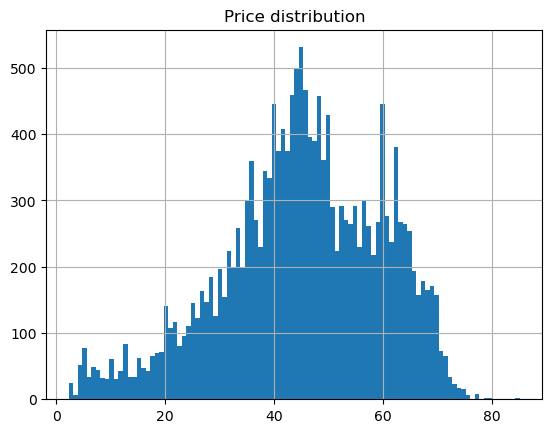

count    17496.000000
mean        45.026782
std         14.658087
min          2.300000
25%         36.100000
50%         45.440000
75%         56.385000
max         85.050000
Name: price day ahead, dtype: float64
Skew: -0.44


In [241]:
import matplotlib.pyplot as plt
train_df[TARGET].hist(bins=100)
plt.title('Price distribution')
plt.show()

print(train_df[TARGET].describe())
print(f"Skew: {train_df[TARGET].skew():.2f}")

## 6. Split Verification
Confirms array shapes and date ranges for each split.

In [242]:
print(f"X_train : {X_train.shape}    y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}      y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}     y_test  : {y_test.shape}")

print(f"\nTrain : {train_df['time'].iloc[0]}  ->  {train_df['time'].iloc[-1]}")
print(f"Val   : {val_df['time'].iloc[0]}  ->  {val_df['time'].iloc[-1]}")
print(f"Test  : {test_df['time'].iloc[0]}  ->  {test_df['time'].iloc[-1]}")

print(f"\nFeature scale check -- X_train : min={X_train.min():.3f}, max={X_train.max():.3f}")
print(f"Target  scale check -- y_train : min={y_train.min():.3f}, max={y_train.max():.3f}")

X_train : (17496, 22)    y_train : (17496,)
X_val   : (8760, 22)      y_val   : (8760,)
X_test  : (8735, 22)     y_test  : (8735,)

Train : 2015-01-03 00:00:00+00:00  ->  2016-12-31 23:00:00+00:00
Val   : 2017-01-01 00:00:00+00:00  ->  2017-12-31 23:00:00+00:00
Test  : 2018-01-01 00:00:00+00:00  ->  2018-12-30 22:00:00+00:00

Feature scale check -- X_train : min=-1.000, max=1.000
Target  scale check -- y_train : min=0.000, max=1.000


## 7. Configuration
Hyperparameters for the data pipeline and Transformer model.

| Parameter | Value | Notes |
|---|---|---|
| `WINDOW_SIZE` | 48 | Hours of look-back the Transformer attends over |
| `HORIZON` | 24 | Hours ahead to forecast |
| `D_MODEL` | 64 | Internal embedding dimension (must be divisible by `N_HEAD`) |
| `N_HEAD` | 4 | Self-attention heads |
| `NUM_ENC_LAYERS` | 2 | Stacked encoder blocks |
| `DIM_FEEDFORWARD` | 256 | FFN hidden dimension inside each encoder block |
| `DROPOUT` | 0.1 | Applied after attention and FFN sub-layers |

In [243]:
WINDOW_SIZE     = 48    # hours of context fed into the Transformer
HORIZON         = 24    # hours ahead to predict
INPUT_SIZE      = len(feature_cols)

D_MODEL         = 64    # embedding dim -- must be divisible by N_HEAD
N_HEAD          = 4
NUM_ENC_LAYERS  = 2
DIM_FEEDFORWARD = 256
DROPOUT         = 0.3   

print(f"Input window     : {WINDOW_SIZE} hours")
print(f"Forecast horizon : {HORIZON} hours")
print(f"Input features   : {INPUT_SIZE}")
print(f"d_model={D_MODEL}, heads={N_HEAD}, enc_layers={NUM_ENC_LAYERS}, ffn={DIM_FEEDFORWARD}")

Input window     : 48 hours
Forecast horizon : 24 hours
Input features   : 22
d_model=64, heads=4, enc_layers=2, ffn=256


## 8. Dataset & DataLoader Construction
`EnergyDataset` slices the data into overlapping windows. For each index the input is the past `WINDOW_SIZE` hours of features and the target is the next `HORIZON` hours of day-ahead price.

In [244]:
class EnergyDataset(Dataset):
    def __init__(self, X, y, window_size=WINDOW_SIZE, horizon=HORIZON):
        self.X           = torch.tensor(X, dtype=torch.float32)
        self.y           = torch.tensor(y, dtype=torch.float32)
        self.window_size = window_size
        self.horizon     = horizon

    def __len__(self):
        return len(self.X) - self.window_size - self.horizon + 1

    def __getitem__(self, idx):
        x_seq = self.X[idx : idx + self.window_size]
        y_seq = self.y[idx + self.window_size : idx + self.window_size + self.horizon]
        return x_seq, y_seq

In [245]:
BATCH_SIZE  = 256 if torch.cuda.is_available() else 64
NUM_WORKERS = 4   if torch.cuda.is_available() else 0
PIN_MEMORY  = torch.cuda.is_available()

train_dataset = EnergyDataset(X_train, y_train)
val_dataset   = EnergyDataset(X_val,   y_val)
test_dataset  = EnergyDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

x_sample, y_sample = next(iter(train_loader))
print(f"X batch : {tuple(x_sample.shape)}  ->  expected (batch, {WINDOW_SIZE}, {INPUT_SIZE})")
print(f"y batch : {tuple(y_sample.shape)}  ->  expected (batch, {HORIZON})")

X batch : (64, 48, 22)  ->  expected (batch, 48, 22)
y batch : (64, 24)  ->  expected (batch, 24)


## 9. Model Architecture

A standard Transformer **encoder-only** pipeline:

1. **Input projection** - linear layer maps each timestep from `INPUT_SIZE` raw features to `D_MODEL` dimensions.
2. **Positional encoding** - adds sinusoidal position signals so the model knows the order of timesteps (Transformers have no built-in sense of sequence order).
3. **Transformer encoder** - `NUM_ENC_LAYERS` stacked encoder blocks, each containing:
   - Multi-head self-attention (`N_HEAD` heads, each of size `D_MODEL // N_HEAD`)
   - Feed-forward network (`DIM_FEEDFORWARD` hidden units)
   - Layer norm + residual connections (built into PyTorch's `TransformerEncoderLayer`)
4. **Output head** - takes the **last timestep's** representation and projects it to `HORIZON` output values via a single linear layer.

In [246]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe       = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


class EnergyTransformer(nn.Module):
    def __init__(self, input_size, d_model=D_MODEL, nhead=N_HEAD,
                 num_encoder_layers=NUM_ENC_LAYERS,
                 dim_feedforward=DIM_FEEDFORWARD,
                 dropout=DROPOUT, horizon=HORIZON):
        super().__init__()
        self.input_proj   = nn.Linear(input_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, dropout)
        encoder_layer     = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True,
        )
        self.transformer  = nn.TransformerEncoder(encoder_layer, num_layers=num_encoder_layers)
        self.output_head  = nn.Linear(d_model, horizon)

    def forward(self, x):
        # x: (batch, window_size, input_size)
        x = self.input_proj(x)        # -> (batch, window_size, d_model)
        x = self.pos_encoding(x)      # -> (batch, window_size, d_model)
        x = self.transformer(x)       # -> (batch, window_size, d_model)
        x = x[:, -1, :]              # last timestep -> (batch, d_model)
        return self.output_head(x)    # -> (batch, horizon)

In [247]:
_model = EnergyTransformer(input_size=INPUT_SIZE)
total_params = sum(p.numel() for p in _model.parameters() if p.requires_grad)
print(f"EnergyTransformer -- {total_params:,} trainable parameters")
print(_model)

EnergyTransformer -- 103,000 trainable parameters
EnergyTransformer(
  (input_proj): Linear(in_features=22, out_features=64, bias=True)
  (pos_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (output_head): Linear(in_features=64, out_features=24, bias=True)
)


## 10. Device Selection
Selects the best available compute device: CUDA (NVIDIA GPU) -> MPS (Apple Silicon) -> CPU.

In [248]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else
    'cpu'
)
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: mps


## 11. Training & Evaluation Functions
`train_model()` uses **MSE loss** for training (smoother gradients than MAE), an Adam optimizer, and a `ReduceLROnPlateau` scheduler that halves the learning rate after 5 epochs without improvement. `test_model()` evaluates on the test set and inverse-transforms predictions back to original price units (EUR/MWh), reporting **MAE** and **RMSE** as the final metrics.

### Custom Loss Function 

In [249]:
import copy

# ── Custom Loss ───────────────────────────────────────────────────────────────
class CustomLoss(nn.Module):
    def __init__(self, alpha=0.1, beta=0.01):
        super(CustomLoss, self).__init__()
        self.alpha = alpha
        self.beta  = beta

    def forward(self, y_pred, y_true):
        y_pred = y_pred.squeeze()
        y_true = y_true.squeeze()

        # ── MAE ──────────────────────────────────────────
        mae = torch.mean(torch.abs(y_true - y_pred))

        # ── JSD ──────────────────────────────────────────
        y_true_soft = torch.softmax(y_true, dim=0)
        y_pred_soft = torch.softmax(y_pred, dim=0)
        m           = 0.5 * (y_true_soft + y_pred_soft)
        kl1         = torch.sum(
            y_true_soft * torch.log(y_true_soft / (m + 1e-8) + 1e-8))
        kl2         = torch.sum(
            y_pred_soft * torch.log(y_pred_soft / (m + 1e-8) + 1e-8))
        jsd         = 0.5 * (kl1 + kl2)

        # ── Smoothness ────────────────────────────────────
        smoothness = torch.mean((y_pred[1:] - y_pred[:-1]) ** 2)

        return mae + self.alpha * jsd + self.beta * smoothness

In [250]:
def train_model(model, train_loader, val_loader,
                num_epochs=50, lr=1e-3, device='cpu',
                print_every=1, loss_fn='mae',
                weight_decay=1e-4, alpha=0.1, beta=0.01):

    model     = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=10, factor=0.5
    )

    # ── Loss selection ────────────────────────────────────────────────────────
    if loss_fn == 'mae':
        criterion  = nn.L1Loss()
        loss_label = 'MAE'
    elif loss_fn == 'mse':
        criterion  = nn.MSELoss()
        loss_label = 'MSE'
    elif loss_fn == 'custom':
        criterion  = CustomLoss(alpha=alpha, beta=beta)
        loss_label = f'Custom (α={alpha} β={beta})'
    else:
        raise ValueError(f"loss_fn must be 'mae', 'mse' or 'custom', got '{loss_fn}'")

    print(f"Training with {loss_label} loss")

    best_val_loss = float('inf')
    best_weights  = copy.deepcopy(model.state_dict())
    history       = {'train_loss': [], 'val_loss': [], 'lr': []}

    for epoch in range(num_epochs):
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                val_losses.append(criterion(model(X_batch), y_batch).item())

        train_loss = float(np.mean(train_losses))
        val_loss   = float(np.mean(val_losses))
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights  = copy.deepcopy(model.state_dict())

        if (epoch + 1) % print_every == 0:
            print(f"Epoch {epoch+1:3d}/{num_epochs}  "
                  f"train={train_loss:.4f}  val={val_loss:.4f}  "
                  f"lr={optimizer.param_groups[0]['lr']:.2e}")

    model.load_state_dict(best_weights)
    print(f"\nBest val loss ({loss_label}): {best_val_loss:.4f}")
    return model, history


## 12. Training Execution
Trains the Transformer on the 2-year training set, monitors on the validation year, then evaluates on the held-out test year.

In [251]:
import time

assert X_train.shape[1] == INPUT_SIZE, (
    f"Feature mismatch: X_train has {X_train.shape[1]} features but "
    f"INPUT_SIZE={INPUT_SIZE}. Re-run cells 6 → 8 → 13 → 17 before training."
)

model = EnergyTransformer(input_size=INPUT_SIZE).to(device)

t0 = time.time()
trained_model, history = train_model(
    model, train_loader, val_loader,
    num_epochs=50, lr=1e-3, device=device, loss_fn='mae', weight_decay=1e-4
)

elapsed = time.time() - t0

mins, secs = divmod(int(elapsed), 60)
print(f"\nTotal training time: {mins}m {secs}s")

Training with MAE loss
Epoch   1/50  train=0.1496  val=0.0902  lr=1.00e-03
Epoch   2/50  train=0.0927  val=0.0875  lr=1.00e-03
Epoch   3/50  train=0.0813  val=0.0816  lr=1.00e-03
Epoch   4/50  train=0.0722  val=0.0648  lr=1.00e-03
Epoch   5/50  train=0.0668  val=0.0708  lr=1.00e-03
Epoch   6/50  train=0.0645  val=0.0653  lr=1.00e-03
Epoch   7/50  train=0.0615  val=0.0626  lr=1.00e-03
Epoch   8/50  train=0.0594  val=0.0674  lr=1.00e-03
Epoch   9/50  train=0.0578  val=0.0640  lr=1.00e-03
Epoch  10/50  train=0.0567  val=0.0720  lr=1.00e-03
Epoch  11/50  train=0.0561  val=0.0716  lr=1.00e-03
Epoch  12/50  train=0.0549  val=0.0659  lr=1.00e-03
Epoch  13/50  train=0.0545  val=0.0642  lr=1.00e-03
Epoch  14/50  train=0.0542  val=0.0641  lr=1.00e-03
Epoch  15/50  train=0.0541  val=0.0704  lr=1.00e-03
Epoch  16/50  train=0.0532  val=0.0671  lr=1.00e-03
Epoch  17/50  train=0.0533  val=0.0672  lr=1.00e-03
Epoch  18/50  train=0.0528  val=0.0704  lr=5.00e-04
Epoch  19/50  train=0.0513  val=0.0686  l

### Total Training Time 

In [252]:
hours, remainder = divmod(int(elapsed), 3600)
mins, secs = divmod(remainder, 60)
print(f"Total training time: {hours}h {mins}m {secs}s")

Total training time: 0h 2m 54s


### Helper functions for testing/evaluation 

In [253]:
def compute_metrics(preds_orig, actuals_orig):
    mae  = float(np.mean(np.abs(preds_orig - actuals_orig)))
    rmse = float(np.sqrt(np.mean((preds_orig - actuals_orig) ** 2)))
    mape = float(np.mean(np.abs((actuals_orig - preds_orig) /
                                 np.abs(actuals_orig).clip(min=1.0))) * 100)
    mae_per_horizon = np.mean(np.abs(preds_orig - actuals_orig), axis=0)
    return mae, rmse, mape, mae_per_horizon


def print_metrics(mae, rmse, mape, mae_per_horizon):
    print(f"MAE  : {mae:.3f} EUR/MWh  (on average, predictions are off by {mae:.1f} EUR/MWh)")
    print(f"RMSE : {rmse:.3f} EUR/MWh  (higher than MAE means occasional big misses)")
    print(f"MAPE : {mape:.2f}%          (on average, predictions are off by {mape:.1f}% of the actual price)")
    print(f"\nPer-horizon MAE (EUR/MWh)  — does error grow the further ahead we predict?")
    for h, m in enumerate(mae_per_horizon, 1):
        bar = '█' * int(m)
        print(f"  h+{h:02d} : {m:6.3f}  {bar}")

### Test using the best model (i.e the one with the lowest validation loss)

In [254]:
def test_model(model, test_loader, tgt_scaler, device='cpu'):
    model.eval()
    all_preds, all_actuals = [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            preds = model(X_batch.to(device)).cpu().numpy()
            all_preds.append(preds)
            all_actuals.append(y_batch.numpy())

    preds   = np.concatenate(all_preds,   axis=0)   # (N, 24)
    actuals = np.concatenate(all_actuals, axis=0)   # (N, 24)

    preds_orig   = tgt_scaler.inverse_transform(preds.reshape(-1, 1)).reshape(preds.shape)
    actuals_orig = tgt_scaler.inverse_transform(actuals.reshape(-1, 1)).reshape(actuals.shape)

    mae, rmse, mape, mae_per_horizon = compute_metrics(preds_orig, actuals_orig)

    print("── Overlapping Evaluation ──")
    print_metrics(mae, rmse, mape, mae_per_horizon)

    return {
        'preds'           : preds_orig,
        'actuals'         : actuals_orig,
        'mae'             : mae,
        'rmse'            : rmse,
        'mape'            : mape,
        'mae_per_horizon' : mae_per_horizon,
        'n_windows'       : len(preds),
    }

### Non-overlapping version 

In [255]:
def forecast_production(model, X_test, y_test, tgt_scaler, device='cpu',
                        window_size=WINDOW_SIZE, horizon=HORIZON):
    model.eval()
    X_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_tensor = torch.tensor(y_test, dtype=torch.float32)
    preds, actuals = [], []

    with torch.no_grad():
        for start in range(0, len(X_test) - window_size - horizon + 1, horizon):
            x_window = X_tensor[start : start + window_size].unsqueeze(0).to(device)
            y_window = y_tensor[start + window_size : start + window_size + horizon].numpy()
            pred     = model(x_window).cpu().numpy()
            preds.append(pred)
            actuals.append(y_window)

    preds   = np.concatenate(preds,  axis=0)   # (N_days, 24)
    actuals = np.stack(actuals,      axis=0)   # (N_days, 24)

    preds_orig   = tgt_scaler.inverse_transform(preds.reshape(-1, 1)).reshape(preds.shape)
    actuals_orig = tgt_scaler.inverse_transform(actuals.reshape(-1, 1)).reshape(actuals.shape)

    mae, rmse, mape, mae_per_horizon = compute_metrics(preds_orig, actuals_orig)

    print(f"── Production Forecast Metrics (non-overlapping, stride={horizon}) ──")
    print(f"Windows : {len(preds)} day-ahead forecasts")
    print_metrics(mae, rmse, mape, mae_per_horizon)

    return {
        'preds'           : preds_orig,        # (N_days, 24) — consistent with test_model
        'actuals'         : actuals_orig,      # (N_days, 24)
        'mae'             : mae,
        'rmse'            : rmse,
        'mape'            : mape,
        'mae_per_horizon' : mae_per_horizon,
        'n_windows'       : len(preds),
    }

### Overlapping — how accurate is the model across all possible prediction windows
### Non-overlapping — how accurate is the model simulating real day-ahead operation 

In [256]:
print("── Overlapping Evaluation ──")
results = test_model(trained_model, test_loader, tgt_scaler, device=device)

── Overlapping Evaluation ──
── Overlapping Evaluation ──
MAE  : 5.603 EUR/MWh  (on average, predictions are off by 5.6 EUR/MWh)
RMSE : 7.344 EUR/MWh  (higher than MAE means occasional big misses)
MAPE : 12.81%          (on average, predictions are off by 12.8% of the actual price)

Per-horizon MAE (EUR/MWh)  — does error grow the further ahead we predict?
  h+01 :  4.005  ████
  h+02 :  4.305  ████
  h+03 :  4.703  ████
  h+04 :  4.605  ████
  h+05 :  4.931  ████
  h+06 :  4.980  ████
  h+07 :  5.017  █████
  h+08 :  5.841  █████
  h+09 :  5.638  █████
  h+10 :  6.377  ██████
  h+11 :  6.061  ██████
  h+12 :  6.212  ██████
  h+13 :  5.678  █████
  h+14 :  6.064  ██████
  h+15 :  6.180  ██████
  h+16 :  6.337  ██████
  h+17 :  6.246  ██████
  h+18 :  6.204  ██████
  h+19 :  6.139  ██████
  h+20 :  5.753  █████
  h+21 :  5.560  █████
  h+22 :  5.582  █████
  h+23 :  5.745  █████
  h+24 :  6.301  ██████


In [257]:
print("\n── Non-Overlapping Version (Production Simulation) ──")
prod = forecast_production(trained_model, X_test, y_test, tgt_scaler, device=device)


── Non-Overlapping Version (Production Simulation) ──
── Production Forecast Metrics (non-overlapping, stride=24) ──
Windows : 361 day-ahead forecasts
MAE  : 5.364 EUR/MWh  (on average, predictions are off by 5.4 EUR/MWh)
RMSE : 6.980 EUR/MWh  (higher than MAE means occasional big misses)
MAPE : 12.60%          (on average, predictions are off by 12.6% of the actual price)

Per-horizon MAE (EUR/MWh)  — does error grow the further ahead we predict?
  h+01 :  6.109  ██████
  h+02 :  6.518  ██████
  h+03 :  6.993  ██████
  h+04 :  5.913  █████
  h+05 :  6.274  ██████
  h+06 :  5.801  █████
  h+07 :  5.091  █████
  h+08 :  5.215  █████
  h+09 :  4.507  ████
  h+10 :  4.705  ████
  h+11 :  4.499  ████
  h+12 :  4.863  ████
  h+13 :  4.749  ████
  h+14 :  4.810  ████
  h+15 :  4.691  ████
  h+16 :  4.774  ████
  h+17 :  4.755  ████
  h+18 :  4.976  ████
  h+19 :  5.151  █████
  h+20 :  5.006  █████
  h+21 :  4.618  ████
  h+22 :  4.682  ████
  h+23 :  6.013  ██████
  h+24 :  8.029  ████████

## 13. Visualization - Overlapping Version 
Four plots: the first 30 days of the test period (unrolled predictions), a sample 24-hour forecast horizon, the residual distribution, and training/validation loss curves.

In [258]:
def plot_results(results, history, plot_days=30):
    preds   = results['preds']
    actuals = results['actuals']

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Day-Ahead Price Forecast -- Transformer', fontsize=14, fontweight='bold')

    # First N days of test period (sequences unrolled)
    ax        = axes[0, 0]
    n_hours   = plot_days * 24
    n         = min(n_hours, len(preds.ravel()))
    actual_days = n // 24  # how many complete days are actually shown
    ax.plot(actuals.ravel()[:n], label='Actual',    alpha=0.8, linewidth=0.8)
    ax.plot(preds.ravel()[:n],   label='Predicted', alpha=0.8, linewidth=0.8)
    ax.set_title(f'First {actual_days} days of test period')
    ax.set_xlabel('Hour')
    ax.set_ylabel('Price (EUR/MWh)')
    ax.legend()

    # Sample 24h forecast horizon
    ax  = axes[0, 1]
    idx = 200
    ax.plot(range(HORIZON), actuals[idx], marker='o', label='Actual',    linewidth=1.5)
    ax.plot(range(HORIZON), preds[idx],   marker='x', label='Predicted', linewidth=1.5)
    ax.set_title(f'Sample 24 h horizon (sequence #{idx})')
    ax.set_xlabel('Hour ahead')
    ax.set_ylabel('Price (EUR/MWh)')
    ax.legend()

    # Residual distribution
    ax     = axes[1, 0]
    errors = (preds - actuals).ravel()
    ax.hist(errors, bins=60, edgecolor='black', linewidth=0.4)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.2,
            label=f'Zero error (perfect)')
    ax.axvline(results['mae'], color='orange', linestyle='--', linewidth=1.2,
            label=f'MAE = ±{results["mae"]:.2f} EUR/MWh')
    ax.axvline(-results['mae'], color='orange', linestyle='--', linewidth=1.2)
    ax.set_title('Residual distribution')
    ax.set_xlabel('Error (EUR/MWh)')
    ax.set_ylabel('Count')
    ax.legend()

    # Training history
    ax = axes[1, 1]
    ax.plot(history['train_loss'], label='Train (MSE)')
    ax.plot(history['val_loss'],   label='Val (MSE)')
    ax.set_title('Training history')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE loss (scaled)')
    ax.legend()

    plt.tight_layout()
    plt.show()

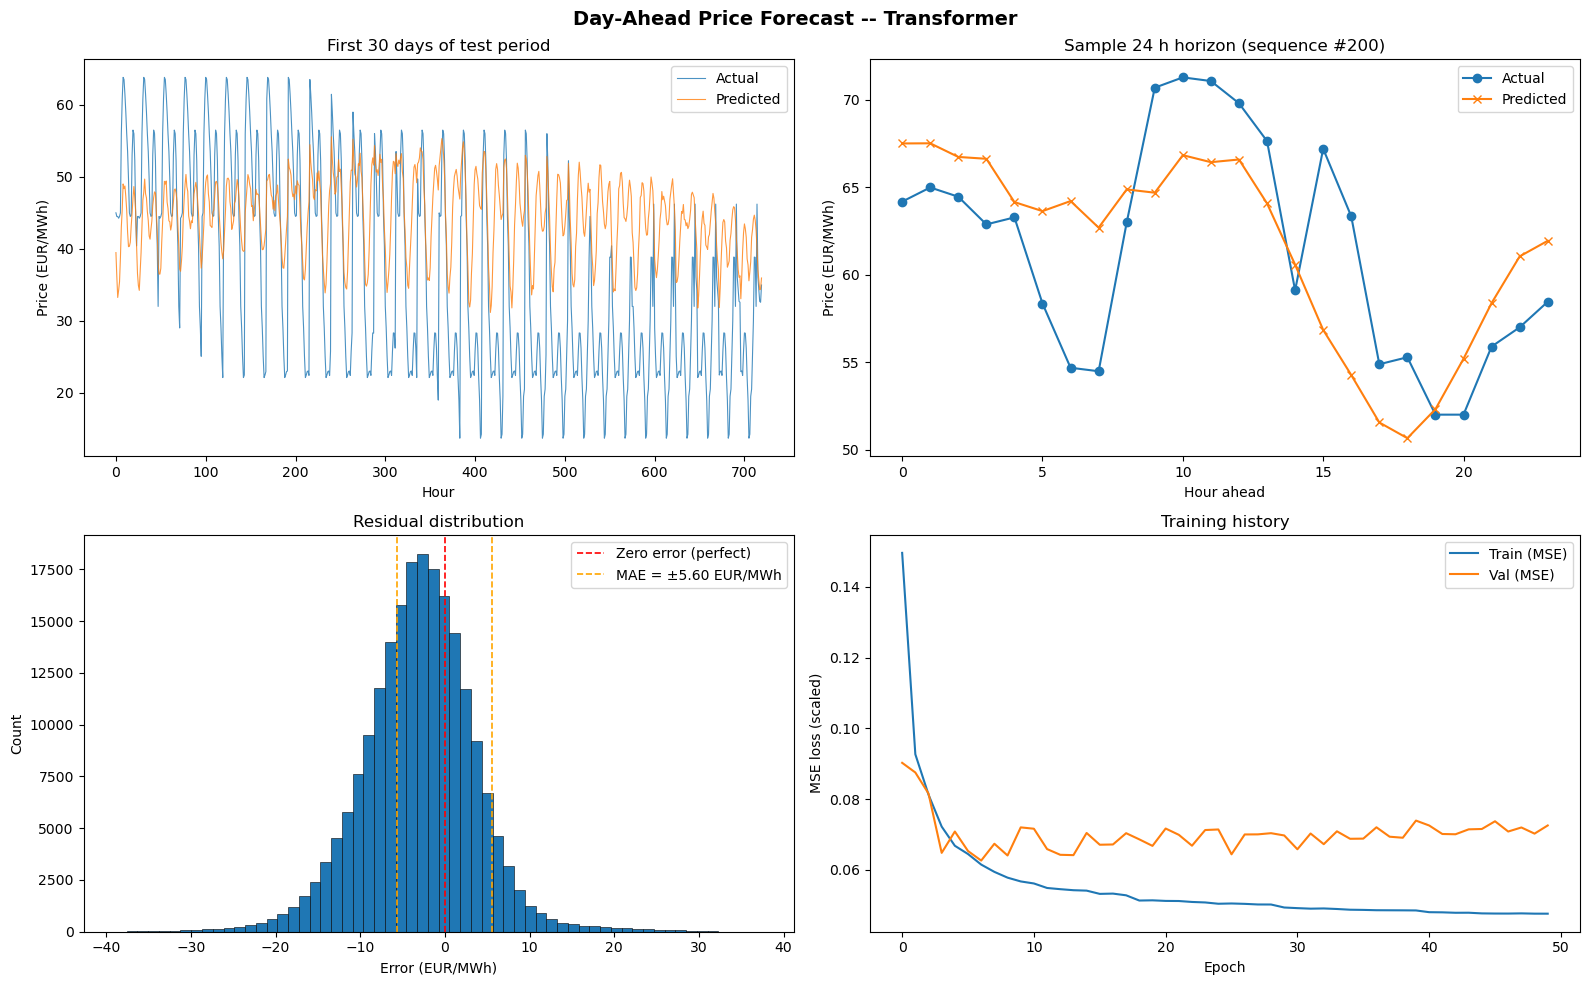

In [259]:
plot_results(results, history, plot_days=30)

### Notes 

In [260]:
# 1. Benchmarking Model Accuracy (what you're doing now)
# Goal: measure how good the model is
# Use all overlapping windows, average the metrics. This is the standard academic approach — maximises the number of evaluation samples so your MAE/RMSE estimate is more statistically stable.
# 8688 overlapping samples → more robust metric estimate


# 2. Realistic Production Forecast (what you'd do in deployment)
# Goal: simulate what the model would actually do in the real world
# In reality a grid operator runs the model once per day and gets a 24-hour forecast. They don't re-run it every hour. So you'd use non-overlapping windows strided by 24:
# sample 0:  input=[hour 0  ... hour 47]  → predicts [hour 48 ... hour 71]
# sample 1:  input=[hour 24 ... hour 71]  → predicts [hour 72 ... hour 95]
# sample 2:  input=[hour 48 ... hour 95]  → predicts [hour 96 ... hour 119]

# This gives you ~364 clean non-overlapping day-ahead forecasts covering all of 2018, one prediction per hour, no overlap.

In [261]:
# error = pred - actual < 0
# → predicted > actual
# → model thinks prices will be higher than they are
